<a href="https://colab.research.google.com/github/Triveni18/Python/blob/main/EDA/EDADemoTitanicDataset01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  First 5 rows (head) 

   PassengerId  Survived  Pclass                                               Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                            Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                             Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5         0       3                           Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S

  Last 5 rows (tail) 

     PassengerId  Survived 

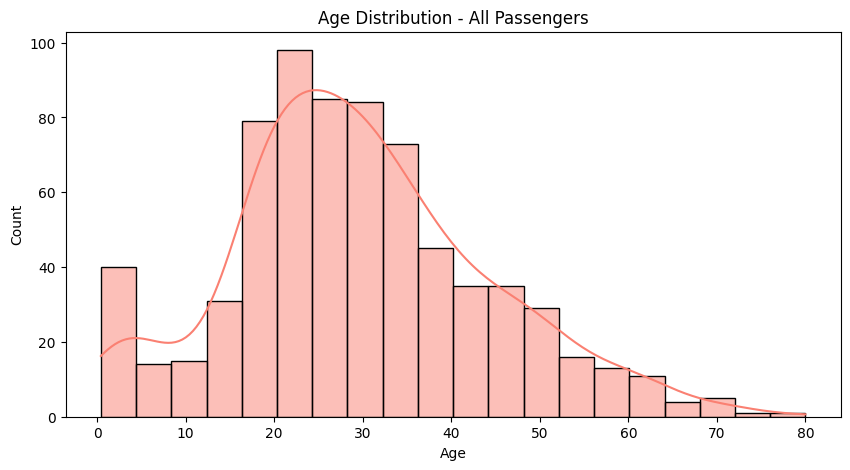

/tmp/ipykernel_1630/1291285080.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=survived, x='Sex', palette='Set2')


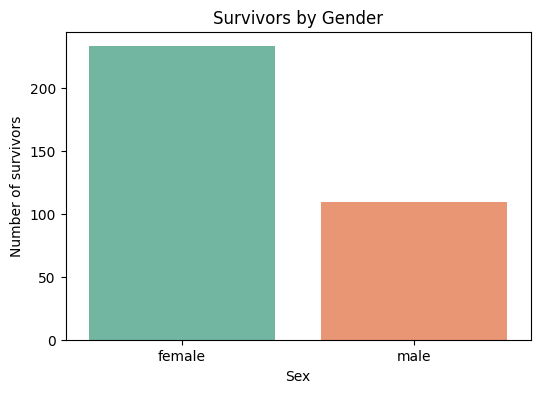

/tmp/ipykernel_1630/1291285080.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=survived, x='Pclass', palette='viridis')


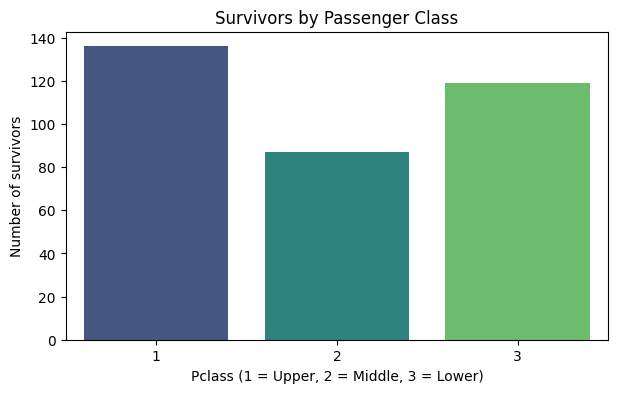

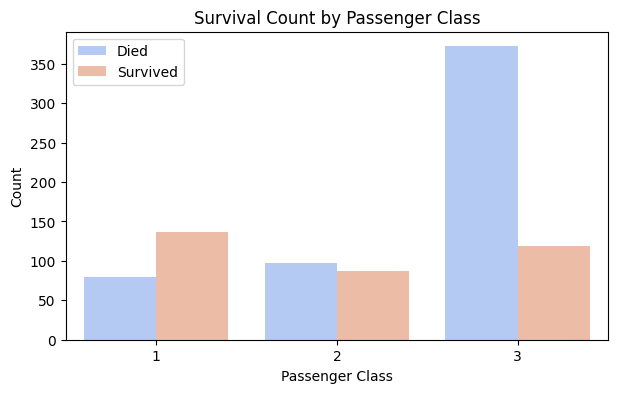


Survival rate by Pclass:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

Survival rate by Sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Age statistics by survival status:
          count       mean        std   min   25%   50%   75%   max
Survived                                                           
0         424.0  30.626179  14.172110  1.00  21.0  28.0  39.0  74.0
1         290.0  28.343690  14.950952  0.42  19.0  28.0  36.0  80.0


/tmp/ipykernel_1630/1291285080.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Fare', palette='muted')


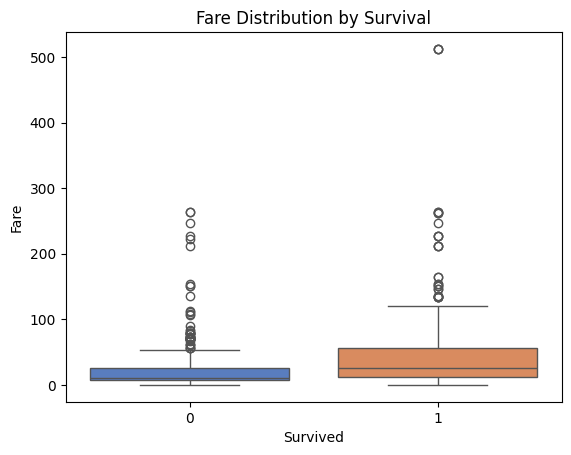

In [14]:
# ───────────────────────────────────────────────
#                TITANIC DATASET EXPLORATION
# ───────────────────────────────────────────────

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make wide tables easier to read in console/notebook
pd.set_option('display.width', 1500)

# ─── 1. Load the data ────────────────────────────────────────
df = pd.read_csv('/content/Titanic-Dataset.csv')

# ─── 2. Quick look at the dataset ─────────────────────────────
print('\n  First 5 rows (head) \n')
print(df.head())

print('\n  Last 5 rows (tail) \n')
print(df.tail())

# ─── 3. Check for missing values ──────────────────────────────
print('\n  Number of missing values per column \n')
data_null = df.isnull().sum()
print(data_null)

# Most common column to check individually
age_null = df['Age'].isnull().sum()
print(f'\n  Missing values in Age column: {age_null}\n')

# ─── 4. Basic survival statistics ─────────────────────────────
survived = df[df['Survived'] == 1]
not_survived = df[df['Survived'] == 0]

print(f'Number of passengers who survived  : {len(survived)}')
print(f'Number of passengers who died      : {len(not_survived)}')
print(f'Survival rate                      : {len(survived)/len(df):.1%}\n')

# ─── 5. Age column without missing values ─────────────────────
age_clean = df['Age'].dropna()
print(f'Number of valid (non-null) Age values: {len(age_clean)}')
print(f'→ {df["Age"].isnull().mean():.1%} of Age values are missing\n')

# ─── 6. Quick look at survivors' names & ages ─────────────────
print('\nSome information about survivors:\n')
print(df[['Name', 'Age', 'Sex', 'Pclass']][df['Survived'] == 1].head(8))

# ─── 7. Select only numeric columns ───────────────────────────
numeric_df = df.select_dtypes(include=['float64', 'int64'])
print('\nNumeric columns only:\n')
print(numeric_df.columns.tolist())

# ─── 8. Visualizations ────────────────────────────────────────

# Age distribution (full dataset)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', bins=20, kde=True, color='salmon')
plt.title('Age Distribution - All Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Gender distribution among survivors
plt.figure(figsize=(6, 4))
sns.countplot(data=survived, x='Sex', palette='Set2')
plt.title('Survivors by Gender')
plt.xlabel('Sex')
plt.ylabel('Number of survivors')
plt.show()

# Passenger class distribution among survivors
plt.figure(figsize=(7, 4))
sns.countplot(data=survived, x='Pclass', palette='viridis')
plt.title('Survivors by Passenger Class')
plt.xlabel('Pclass (1 = Upper, 2 = Middle, 3 = Lower)')
plt.ylabel('Number of survivors')
plt.show()

# Bonus: survival rate by class (more insightful version)
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Pclass', hue='Survived', palette='coolwarm')
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])
plt.show()

# ─── Ideas for further exploration ────────────────────────────

# Survival rate by class
print("\nSurvival rate by Pclass:")
print(df.groupby('Pclass')['Survived'].mean().round(3))

# Survival rate by sex
print("\nSurvival rate by Sex:")
print(df.groupby('Sex')['Survived'].mean().round(3))

# Age statistics by survival
print("\nAge statistics by survival status:")
print(df.groupby('Survived')['Age'].describe())

# Fare vs Survival (boxplot)
sns.boxplot(data=df, x='Survived', y='Fare', palette='muted')
plt.title('Fare Distribution by Survival')
plt.show()